# Load necessary files

In [217]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

# Elman RNN

In [248]:
tokens = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

class ElmanRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(ElmanRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, len(tokens))
        self.fc2 = nn.Linear(len(tokens), len(tokens))
        
    def forward(self, x, h0=None):
        if h0 == None:
            h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
            
        out, h0 = self.rnn(x, h0)
        out = torch.nn.functional.relu(self.fc1(out[:, -1, :]))
        out = self.fc2(out)
        out = torch.nn.functional.softmax(out, dim=1)
        return out, h0

In [164]:
class Dataset_converter(Dataset):
    def __init__(self, data, window=2):
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((len(data)-window, window, len(tokens)))
        self.y = np.zeros((len(data)-window, len(tokens)))

        for ii in range(len(data)-window):
            self.X[ii] = one_hot_encoded[ii:ii+window,:]
            self.y[ii] = one_hot_encoded[ii+window,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [238]:
class Dataset_converter_compressed(Dataset):
    def __init__(self, data, window=2, compression=2):
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros(((len(data)-window)//compression, window, len(tokens)))
        self.y = np.zeros(((len(data)-window)//compression, len(tokens)))

        for ii in range(len(data)-window):
            if ii%compression:
                continue
                
            self.X[ii] = one_hot_encoded[ii:ii+window,:]
            self.y[ii] = one_hot_encoded[ii+window,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

## Load dataset

In [165]:
data = pd.read_csv("../Seq_500000.txt")['seq'][0]

In [188]:
reps = 5
context_window = 1
lr = 1e-2

test_acc_rnn = np.zeros((reps, len(data)-1), dtype=float)


data_set = Dataset_converter(data, window=context_window)

for rep in tqdm(range(reps)):
    torch.manual_seed(rep)
    model = ElmanRNN(len(tokens), 20, 1)
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.MSELoss()

    total = 0
    correct = 0
    jj = 0
    for X, y in train_loader:
        optimizer.zero_grad()

        if jj==0:
            predicted_y, hidden_memory = model(X)
        else:
            predicted_y, hidden_memory = model(X, mem)

        loss = criterion(predicted_y, y)
        loss.backward()

        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()

        with torch.no_grad():
            mem = hidden_memory.clone()
            total += 1
            
            if y.argmax() == predicted_y.argmax():
                    correct += 1

            test_acc_rnn[rep,jj] = correct/total

            if jj%10000 == 0:
                print(f'Iter : {jj+1}, loss: {loss:.4f}')
            jj += 1
            

  0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]

Iter : 1, loss: 0.1212
Iter : 10001, loss: 0.0939
Iter : 20001, loss: 0.0798
Iter : 30001, loss: 0.0843
Iter : 40001, loss: 0.0804
Iter : 50001, loss: 0.0985
Iter : 60001, loss: 0.0716
Iter : 70001, loss: 0.0680
Iter : 80001, loss: 0.0846
Iter : 90001, loss: 0.0504
Iter : 100001, loss: 0.0616
Iter : 110001, loss: 0.0468
Iter : 120001, loss: 0.0636
Iter : 130001, loss: 0.0747
Iter : 140001, loss: 0.0742
Iter : 150001, loss: 0.0802
Iter : 160001, loss: 0.0618
Iter : 170001, loss: 0.0972
Iter : 180001, loss: 0.0678
Iter : 190001, loss: 0.0857
Iter : 200001, loss: 0.0614
Iter : 210001, loss: 0.0794
Iter : 220001, loss: 0.0686
Iter : 230001, loss: 0.0703
Iter : 240001, loss: 0.0510
Iter : 250001, loss: 0.0825
Iter : 260001, loss: 0.0737
Iter : 270001, loss: 0.0741
Iter : 280001, loss: 0.0609
Iter : 290001, loss: 0.0957
Iter : 300001, loss: 0.0847
Iter : 310001, loss: 0.0765
Iter : 320001, loss: 0.1059
Iter : 330001, loss: 0.0629
Iter : 340001, loss: 0.0840
Iter : 350001, loss: 0.0592
Iter :

 20%|███████████████████████████▊                                                                                                               | 1/5 [02:34<10:17, 154.27s/it]

Iter : 1, loss: 0.1159
Iter : 10001, loss: 0.1287
Iter : 20001, loss: 0.0792
Iter : 30001, loss: 0.0822
Iter : 40001, loss: 0.0774
Iter : 50001, loss: 0.1024
Iter : 60001, loss: 0.0694
Iter : 70001, loss: 0.0738
Iter : 80001, loss: 0.0787
Iter : 90001, loss: 0.0592
Iter : 100001, loss: 0.0623
Iter : 110001, loss: 0.0492
Iter : 120001, loss: 0.0656
Iter : 130001, loss: 0.0756
Iter : 140001, loss: 0.0726
Iter : 150001, loss: 0.0799
Iter : 160001, loss: 0.0627
Iter : 170001, loss: 0.0957
Iter : 180001, loss: 0.0677
Iter : 190001, loss: 0.0857
Iter : 200001, loss: 0.0637
Iter : 210001, loss: 0.0810
Iter : 220001, loss: 0.0675
Iter : 230001, loss: 0.0725
Iter : 240001, loss: 0.0521
Iter : 250001, loss: 0.0820
Iter : 260001, loss: 0.0735
Iter : 270001, loss: 0.0750
Iter : 280001, loss: 0.0620
Iter : 290001, loss: 0.0993
Iter : 300001, loss: 0.0880
Iter : 310001, loss: 0.0755
Iter : 320001, loss: 0.1055
Iter : 330001, loss: 0.0637
Iter : 340001, loss: 0.0850
Iter : 350001, loss: 0.0613
Iter :

 40%|███████████████████████████████████████████████████████▌                                                                                   | 2/5 [05:09<07:43, 154.57s/it]

...

 60%|███████████████████████████████████████████████████████████████████████████████████▍                                                       | 3/5 [07:45<05:10, 155.45s/it]

Iter : 1, loss: 0.1104
Iter : 10001, loss: 0.1566
Iter : 20001, loss: 0.0786
Iter : 30001, loss: 0.0798
Iter : 40001, loss: 0.0730
Iter : 50001, loss: 0.0986
Iter : 60001, loss: 0.0706
Iter : 70001, loss: 0.0709
Iter : 80001, loss: 0.0814
Iter : 90001, loss: 0.0498
Iter : 100001, loss: 0.0627
Iter : 110001, loss: 0.0462
Iter : 120001, loss: 0.0634
Iter : 130001, loss: 0.0753
Iter : 140001, loss: 0.0744
Iter : 150001, loss: 0.0791
Iter : 160001, loss: 0.0621
Iter : 170001, loss: 0.0978
Iter : 180001, loss: 0.0737
Iter : 190001, loss: 0.0862
Iter : 200001, loss: 0.0527
Iter : 210001, loss: 0.0967
Iter : 220001, loss: 0.0653
Iter : 230001, loss: 0.0754
Iter : 240001, loss: 0.0478
Iter : 250001, loss: 0.0911
Iter : 260001, loss: 0.0722
Iter : 270001, loss: 0.0644
Iter : 280001, loss: 0.0590
Iter : 290001, loss: 0.1066
Iter : 300001, loss: 0.0850
Iter : 310001, loss: 0.0866
Iter : 320001, loss: 0.1013
Iter : 330001, loss: 0.0645
Iter : 340001, loss: 0.0834
Iter : 350001, loss: 0.0605
Iter :

 80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                           | 4/5 [10:21<02:35, 155.48s/it]

Iter : 1, loss: 0.1380
Iter : 10001, loss: 0.1155
Iter : 20001, loss: 0.0992
Iter : 30001, loss: 0.0794
Iter : 40001, loss: 0.0774
Iter : 50001, loss: 0.1072
Iter : 60001, loss: 0.0759
Iter : 70001, loss: 0.0651
Iter : 80001, loss: 0.0965
Iter : 90001, loss: 0.0397
Iter : 100001, loss: 0.0544
Iter : 110001, loss: 0.0431
Iter : 120001, loss: 0.0573
Iter : 130001, loss: 0.0815
Iter : 140001, loss: 0.0696
Iter : 150001, loss: 0.0774
Iter : 160001, loss: 0.0588
Iter : 170001, loss: 0.1039
Iter : 180001, loss: 0.0726
Iter : 190001, loss: 0.0865
Iter : 200001, loss: 0.0597
Iter : 210001, loss: 0.0799
Iter : 220001, loss: 0.0685
Iter : 230001, loss: 0.0666
Iter : 240001, loss: 0.0526
Iter : 250001, loss: 0.0861
Iter : 260001, loss: 0.0719
Iter : 270001, loss: 0.0724
Iter : 280001, loss: 0.0592
Iter : 290001, loss: 0.0966
Iter : 300001, loss: 0.0837
Iter : 310001, loss: 0.0776
Iter : 320001, loss: 0.1034
Iter : 330001, loss: 0.0643
Iter : 340001, loss: 0.0855
Iter : 350001, loss: 0.0616
Iter :

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [12:53<00:00, 154.66s/it]


In [189]:
reps = 5
context_window = 1
lr = 1e-2

test_acc_rnn_ = np.zeros((reps, len(data)-1), dtype=float)


data_set = Dataset_converter(data, window=context_window)

for rep in tqdm(range(reps)):
    torch.manual_seed(rep)
    model = ElmanRNN(len(tokens), 20, 1)
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.MSELoss()

    total = 0
    correct = 0
    jj = 0
    for X, y in train_loader:
        optimizer.zero_grad()

        if jj==0:
            predicted_y, hidden_memory = model(X)
        else:
            predicted_y, hidden_memory = model(X)

        loss = criterion(predicted_y, y)
        loss.backward()

        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()

        with torch.no_grad():
            mem = hidden_memory.clone()
            total += 1
            
            if y.argmax() == predicted_y.argmax():
                    correct += 1

            test_acc_rnn_[rep,jj] = correct/total

            if jj%10000 == 0:
                print(f'Iter : {jj+1}, loss: {loss:.4f}')
            jj += 1
            

  0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]

Iter : 1, loss: 0.1212
Iter : 10001, loss: 0.1222
Iter : 20001, loss: 0.0982
Iter : 30001, loss: 0.0742
Iter : 40001, loss: 0.0869
Iter : 50001, loss: 0.1000
Iter : 60001, loss: 0.0661
Iter : 70001, loss: 0.0710
Iter : 80001, loss: 0.0863
Iter : 90001, loss: 0.0442
Iter : 100001, loss: 0.0600
Iter : 110001, loss: 0.0478
Iter : 120001, loss: 0.0638
Iter : 130001, loss: 0.0758
Iter : 140001, loss: 0.0723
Iter : 150001, loss: 0.0823
Iter : 160001, loss: 0.0618
Iter : 170001, loss: 0.0990
Iter : 180001, loss: 0.0685
Iter : 190001, loss: 0.0862
Iter : 200001, loss: 0.0636
Iter : 210001, loss: 0.0793
Iter : 220001, loss: 0.0680
Iter : 230001, loss: 0.0700
Iter : 240001, loss: 0.0516
Iter : 250001, loss: 0.0839
Iter : 260001, loss: 0.0734
Iter : 270001, loss: 0.0738
Iter : 280001, loss: 0.0607
Iter : 290001, loss: 0.0948
Iter : 300001, loss: 0.0827
Iter : 310001, loss: 0.0764
Iter : 320001, loss: 0.1029
Iter : 330001, loss: 0.0628
Iter : 340001, loss: 0.0839
Iter : 350001, loss: 0.0615
Iter :

 20%|███████████████████████████▊                                                                                                               | 1/5 [02:26<09:46, 146.66s/it]

Iter : 1, loss: 0.1159
Iter : 10001, loss: 0.1188
Iter : 20001, loss: 0.0885
Iter : 30001, loss: 0.0747
Iter : 40001, loss: 0.0715
Iter : 50001, loss: 0.1010
Iter : 60001, loss: 0.0691
Iter : 70001, loss: 0.0699
Iter : 80001, loss: 0.0842
Iter : 90001, loss: 0.0463
Iter : 100001, loss: 0.0602
Iter : 110001, loss: 0.0453
Iter : 120001, loss: 0.0592
Iter : 130001, loss: 0.0792
Iter : 140001, loss: 0.0717
Iter : 150001, loss: 0.0794
Iter : 160001, loss: 0.0622
Iter : 170001, loss: 0.1074
Iter : 180001, loss: 0.0749
Iter : 190001, loss: 0.0849
Iter : 200001, loss: 0.0595
Iter : 210001, loss: 0.0790
Iter : 220001, loss: 0.0680
Iter : 230001, loss: 0.0685
Iter : 240001, loss: 0.0464
Iter : 250001, loss: 0.0911
Iter : 260001, loss: 0.0723
Iter : 270001, loss: 0.0770
Iter : 280001, loss: 0.0555
Iter : 290001, loss: 0.0986
Iter : 300001, loss: 0.0837
Iter : 310001, loss: 0.0800
Iter : 320001, loss: 0.1043
Iter : 330001, loss: 0.0616
Iter : 340001, loss: 0.0846
Iter : 350001, loss: 0.0617
Iter :

 40%|███████████████████████████████████████████████████████▌                                                                                   | 2/5 [04:53<07:19, 146.50s/it]

...

 60%|███████████████████████████████████████████████████████████████████████████████████▍                                                       | 3/5 [07:19<04:53, 146.58s/it]

Iter : 1, loss: 0.1104
Iter : 10001, loss: 0.1042
Iter : 20001, loss: 0.0846
Iter : 30001, loss: 0.0770
Iter : 40001, loss: 0.0757
Iter : 50001, loss: 0.0986
Iter : 60001, loss: 0.0653
Iter : 70001, loss: 0.0737
Iter : 80001, loss: 0.0804
Iter : 90001, loss: 0.0494
Iter : 100001, loss: 0.0623
Iter : 110001, loss: 0.0489
Iter : 120001, loss: 0.0645
Iter : 130001, loss: 0.0766
Iter : 140001, loss: 0.0758
Iter : 150001, loss: 0.0808
Iter : 160001, loss: 0.0632
Iter : 170001, loss: 0.1009
Iter : 180001, loss: 0.0690
Iter : 190001, loss: 0.0877
Iter : 200001, loss: 0.0626
Iter : 210001, loss: 0.0789
Iter : 220001, loss: 0.0686
Iter : 230001, loss: 0.0701
Iter : 240001, loss: 0.0510
Iter : 250001, loss: 0.0837
Iter : 260001, loss: 0.0733
Iter : 270001, loss: 0.0746
Iter : 280001, loss: 0.0622
Iter : 290001, loss: 0.0978
Iter : 300001, loss: 0.0826
Iter : 310001, loss: 0.0771
Iter : 320001, loss: 0.1027
Iter : 330001, loss: 0.0628
Iter : 340001, loss: 0.0837
Iter : 350001, loss: 0.0598
Iter :

 80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                           | 4/5 [09:46<02:26, 146.69s/it]

Iter : 1, loss: 0.1380
Iter : 10001, loss: 0.1264
Iter : 20001, loss: 0.1140
Iter : 30001, loss: 0.0669
Iter : 40001, loss: 0.0744
Iter : 50001, loss: 0.0989
Iter : 60001, loss: 0.0613
Iter : 70001, loss: 0.0633
Iter : 80001, loss: 0.1000
Iter : 90001, loss: 0.0339
Iter : 100001, loss: 0.0506
Iter : 110001, loss: 0.0419
Iter : 120001, loss: 0.0522
Iter : 130001, loss: 0.0877
Iter : 140001, loss: 0.0751
Iter : 150001, loss: 0.0743
Iter : 160001, loss: 0.0619
Iter : 170001, loss: 0.1152
Iter : 180001, loss: 0.0844
Iter : 190001, loss: 0.0837
Iter : 200001, loss: 0.0620
Iter : 210001, loss: 0.0786
Iter : 220001, loss: 0.0664
Iter : 230001, loss: 0.0675
Iter : 240001, loss: 0.0445
Iter : 250001, loss: 0.0923
Iter : 260001, loss: 0.0714
Iter : 270001, loss: 0.0712
Iter : 280001, loss: 0.0565
Iter : 290001, loss: 0.0993
Iter : 300001, loss: 0.0822
Iter : 310001, loss: 0.0788
Iter : 320001, loss: 0.1063
Iter : 330001, loss: 0.0606
Iter : 340001, loss: 0.0849
Iter : 350001, loss: 0.0638
Iter :

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [12:13<00:00, 146.62s/it]


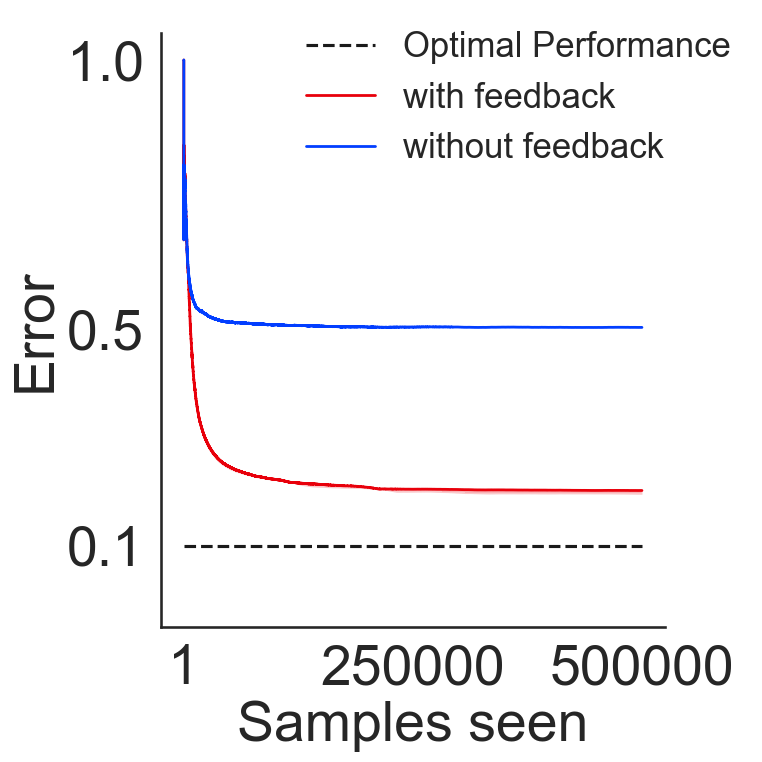

In [190]:
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40
samples_to_show = 500000

fig, ax = plt.subplots(1, 1, figsize=(8,8))

ax.hlines(0.1, 0, samples_to_show, linestyles='dashed', label='Optimal Performance', color='k')

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc_rnn[:5,:samples_to_show],axis=0),linewidth=2, c='r', label='with feedback')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc_rnn[:5,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc_rnn[:5,:samples_to_show], 0.75, axis=0), facecolor='r', alpha=.3)

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc_rnn_[:5,:samples_to_show],axis=0),linewidth=2, c='b', label='without feedback')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc_rnn_[:5,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc_rnn_[:5,:samples_to_show], 0.75, axis=0), facecolor='b', alpha=.3)

leg = fig.legend(fontsize=25, frameon=False)


ax.set_xticks([1, samples_to_show//2, samples_to_show])
ax.set_yticks([0.1, 0.5, 1.0])

ax.set_xlabel('Samples seen', fontsize=font)
ax.set_ylabel('Error', fontsize=font)

ax.tick_params(labelsize=40)
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

plt.tight_layout()


In [184]:
reps = 5
context_window = 5
lr = 1e-2

test_acc_rnn = np.zeros((reps, len(data)-1), dtype=float)


data_set = Dataset_converter(data, window=context_window)

for rep in tqdm(range(reps)):
    torch.manual_seed(rep)
    model = ElmanRNN(len(tokens), 20, 1)
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.MSELoss()

    total = 0
    correct = 0
    jj = 0
    for X, y in train_loader:
        optimizer.zero_grad()

        if jj==0:
            predicted_y, hidden_memory = model(X)
        else:
            predicted_y, hidden_memory = model(X, mem)

        loss = criterion(predicted_y, y)
        loss.backward()

        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()

        with torch.no_grad():
            mem = hidden_memory.clone()
            total += 1
            
            if y.argmax() == predicted_y.argmax():
                    correct += 1

            test_acc_rnn[rep,jj] = correct/total

            if jj%10000 == 0:
                print(f'Iter : {jj+1}, loss: {loss:.4f}')
            jj += 1
            

  0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]

Iter : 1, loss: 0.1272
Iter : 10001, loss: 0.0017
Iter : 20001, loss: 0.0002
Iter : 30001, loss: 0.0003
Iter : 40001, loss: 0.0000
Iter : 50001, loss: 0.0000
Iter : 60001, loss: 0.0000
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

 20%|███████████████████████████▊                                                                                                               | 1/5 [03:23<13:35, 203.96s/it]

Iter : 1, loss: 0.1212
Iter : 10001, loss: 0.0003
Iter : 20001, loss: 0.0000
Iter : 30001, loss: 0.0001
Iter : 40001, loss: 0.0000
Iter : 50001, loss: 0.0000
Iter : 60001, loss: 0.0000
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0001
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

 40%|███████████████████████████████████████████████████████▌                                                                                   | 2/5 [06:57<10:28, 209.57s/it]

...

 60%|███████████████████████████████████████████████████████████████████████████████████▍                                                       | 3/5 [10:22<06:55, 207.61s/it]

Iter : 1, loss: 0.1327
Iter : 10001, loss: 0.0003
Iter : 20001, loss: 0.0000
Iter : 30001, loss: 0.0000
Iter : 40001, loss: 0.0000
Iter : 50001, loss: 0.0000
Iter : 60001, loss: 0.0000
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

 80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                           | 4/5 [13:52<03:28, 208.62s/it]

Iter : 1, loss: 0.1046
Iter : 10001, loss: 0.0003
Iter : 20001, loss: 0.0002
Iter : 30001, loss: 0.0000
Iter : 40001, loss: 0.0002
Iter : 50001, loss: 0.0000
Iter : 60001, loss: 0.0002
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [17:17<00:00, 207.58s/it]


In [185]:
reps = 5
context_window = 5
lr = 1e-2

test_acc_rnn_ = np.zeros((reps, len(data)-1), dtype=float)


data_set = Dataset_converter(data, window=context_window)

for rep in tqdm(range(reps)):
    torch.manual_seed(rep)
    model = ElmanRNN(len(tokens), 20, 1)
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.MSELoss()

    total = 0
    correct = 0
    jj = 0
    for X, y in train_loader:
        optimizer.zero_grad()

        if jj==0:
            predicted_y, hidden_memory = model(X)
        else:
            predicted_y, hidden_memory = model(X)

        loss = criterion(predicted_y, y)
        loss.backward()

        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()

        with torch.no_grad():
            mem = hidden_memory.clone()
            total += 1
            
            if y.argmax() == predicted_y.argmax():
                    correct += 1

            test_acc_rnn_[rep,jj] = correct/total

            if jj%10000 == 0:
                print(f'Iter : {jj+1}, loss: {loss:.4f}')
            jj += 1
            

  0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]

Iter : 1, loss: 0.1272
Iter : 10001, loss: 0.0005
Iter : 20001, loss: 0.0001
Iter : 30001, loss: 0.0000
Iter : 40001, loss: 0.0001
Iter : 50001, loss: 0.0000
Iter : 60001, loss: 0.0000
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

 20%|███████████████████████████▊                                                                                                               | 1/5 [03:16<13:07, 196.79s/it]

Iter : 1, loss: 0.1212
Iter : 10001, loss: 0.0004
Iter : 20001, loss: 0.0000
Iter : 30001, loss: 0.0001
Iter : 40001, loss: 0.0000
Iter : 50001, loss: 0.0001
Iter : 60001, loss: 0.0000
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

 40%|███████████████████████████████████████████████████████▌                                                                                   | 2/5 [06:32<09:49, 196.41s/it]

...

 60%|███████████████████████████████████████████████████████████████████████████████████▍                                                       | 3/5 [09:49<06:32, 196.50s/it]

Iter : 1, loss: 0.1327
Iter : 10001, loss: 0.0003
Iter : 20001, loss: 0.0001
Iter : 30001, loss: 0.0000
Iter : 40001, loss: 0.0000
Iter : 50001, loss: 0.0000
Iter : 60001, loss: 0.0000
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

 80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                           | 4/5 [13:05<03:16, 196.45s/it]

Iter : 1, loss: 0.1046
Iter : 10001, loss: 0.0003
Iter : 20001, loss: 0.0002
Iter : 30001, loss: 0.0001
Iter : 40001, loss: 0.0002
Iter : 50001, loss: 0.0000
Iter : 60001, loss: 0.0001
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [16:22<00:00, 196.50s/it]


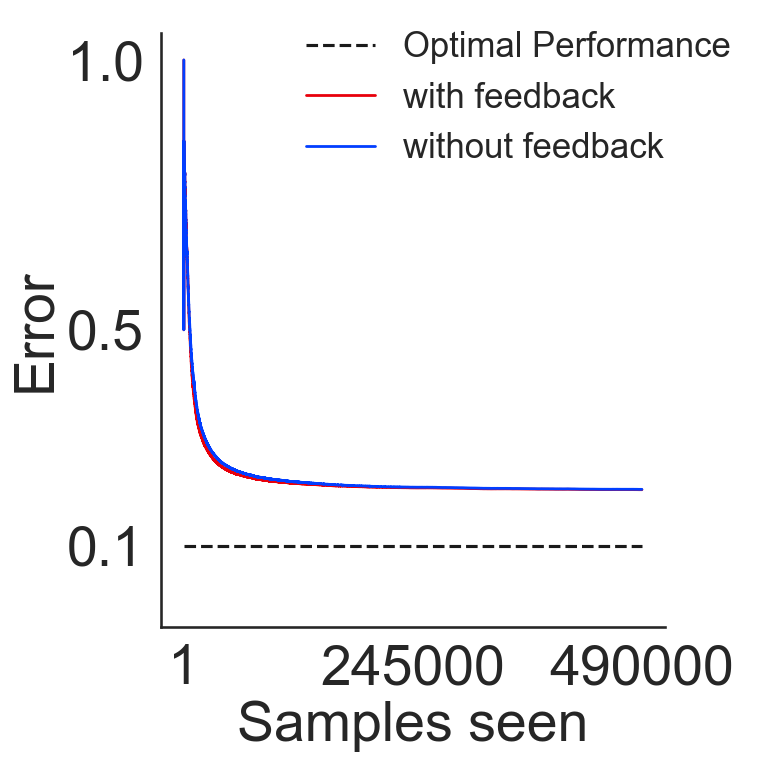

In [187]:
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40
samples_to_show = 490000

fig, ax = plt.subplots(1, 1, figsize=(8,8))

ax.hlines(0.1, 0, samples_to_show, linestyles='dashed', label='Optimal Performance', color='k')

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc_rnn[:5,:samples_to_show],axis=0),linewidth=2, c='r', label='with feedback')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc_rnn[:5,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc_rnn[:5,:samples_to_show], 0.75, axis=0), facecolor='r', alpha=.3)

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc_rnn_[:5,:samples_to_show],axis=0),linewidth=2, c='b', label='without feedback')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc_rnn_[:5,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc_rnn_[:5,:samples_to_show], 0.75, axis=0), facecolor='b', alpha=.3)

leg = fig.legend(fontsize=25, frameon=False)


ax.set_xticks([1, samples_to_show//2, samples_to_show])
ax.set_yticks([0.1, 0.5, 1.0])

ax.set_xlabel('Samples seen', fontsize=font)
ax.set_ylabel('Error', fontsize=font)

ax.tick_params(labelsize=40)
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

plt.tight_layout()


In [191]:
reps = 5
context_window = 8
lr = 1e-2

test_acc_rnn = np.zeros((reps, len(data)-1), dtype=float)


data_set = Dataset_converter(data, window=context_window)

for rep in tqdm(range(reps)):
    torch.manual_seed(rep)
    model = ElmanRNN(len(tokens), 20, 1)
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.MSELoss()

    total = 0
    correct = 0
    jj = 0
    for X, y in train_loader:
        optimizer.zero_grad()

        if jj==0:
            predicted_y, hidden_memory = model(X)
        else:
            predicted_y, hidden_memory = model(X, mem)

        loss = criterion(predicted_y, y)
        loss.backward()

        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()

        with torch.no_grad():
            mem = hidden_memory.clone()
            total += 1
            
            if y.argmax() == predicted_y.argmax():
                    correct += 1

            test_acc_rnn[rep,jj] = correct/total

            if jj%10000 == 0:
                print(f'Iter : {jj+1}, loss: {loss:.4f}')
            jj += 1
            

  0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]

Iter : 1, loss: 0.1307
Iter : 10001, loss: 0.0423
Iter : 20001, loss: 0.0009
Iter : 30001, loss: 0.0005
Iter : 40001, loss: 0.0001
Iter : 50001, loss: 0.0001
Iter : 60001, loss: 0.0001
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0002
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0002
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0001
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0001
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

 20%|███████████████████████████▊                                                                                                               | 1/5 [04:03<16:15, 243.85s/it]

Iter : 1, loss: 0.1232
Iter : 10001, loss: 0.0022
Iter : 20001, loss: 0.0001
Iter : 30001, loss: 0.0001
Iter : 40001, loss: 0.0000
Iter : 50001, loss: 0.0000
Iter : 60001, loss: 0.0000
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

 40%|███████████████████████████████████████████████████████▌                                                                                   | 2/5 [08:05<12:07, 242.55s/it]

...

 60%|███████████████████████████████████████████████████████████████████████████████████▍                                                       | 3/5 [12:06<08:03, 241.74s/it]

Iter : 1, loss: 0.1200
Iter : 10001, loss: 0.0053
Iter : 20001, loss: 0.0001
Iter : 30001, loss: 0.0000
Iter : 40001, loss: 0.0000
Iter : 50001, loss: 0.0000
Iter : 60001, loss: 0.0000
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

 80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                           | 4/5 [16:07<04:01, 241.59s/it]

Iter : 1, loss: 0.1329
Iter : 10001, loss: 0.0024
Iter : 20001, loss: 0.0004
Iter : 30001, loss: 0.0001
Iter : 40001, loss: 0.0001
Iter : 50001, loss: 0.0001
Iter : 60001, loss: 0.0000
Iter : 70001, loss: 0.0001
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [20:08<00:00, 241.64s/it]


In [192]:
reps = 5
context_window = 8
lr = 1e-2

test_acc_rnn_ = np.zeros((reps, len(data)-1), dtype=float)


data_set = Dataset_converter(data, window=context_window)

for rep in tqdm(range(reps)):
    torch.manual_seed(rep)
    model = ElmanRNN(len(tokens), 20, 1)
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = torch.nn.MSELoss()

    total = 0
    correct = 0
    jj = 0
    for X, y in train_loader:
        optimizer.zero_grad()

        if jj==0:
            predicted_y, hidden_memory = model(X)
        else:
            predicted_y, hidden_memory = model(X)

        loss = criterion(predicted_y, y)
        loss.backward()

        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()

        with torch.no_grad():
            mem = hidden_memory.clone()
            total += 1
            
            if y.argmax() == predicted_y.argmax():
                    correct += 1

            test_acc_rnn_[rep,jj] = correct/total

            if jj%10000 == 0:
                print(f'Iter : {jj+1}, loss: {loss:.4f}')
            jj += 1
            

  0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]

Iter : 1, loss: 0.1307
Iter : 10001, loss: 0.0476
Iter : 20001, loss: 0.0016
Iter : 30001, loss: 0.0004
Iter : 40001, loss: 0.0003
Iter : 50001, loss: 0.0001
Iter : 60001, loss: 0.0001
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0002
Iter : 90001, loss: 0.0001
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0001
Iter : 130001, loss: 0.0001
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

 20%|███████████████████████████▊                                                                                                               | 1/5 [03:55<15:42, 235.55s/it]

Iter : 1, loss: 0.1232
Iter : 10001, loss: 0.0003
Iter : 20001, loss: 0.0002
Iter : 30001, loss: 0.0000
Iter : 40001, loss: 0.0000
Iter : 50001, loss: 0.0000
Iter : 60001, loss: 0.0000
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

 40%|███████████████████████████████████████████████████████▌                                                                                   | 2/5 [07:52<11:48, 236.26s/it]

...

 60%|███████████████████████████████████████████████████████████████████████████████████▍                                                       | 3/5 [11:49<07:53, 236.73s/it]

Iter : 1, loss: 0.1200
Iter : 10001, loss: 0.0091
Iter : 20001, loss: 0.0002
Iter : 30001, loss: 0.0001
Iter : 40001, loss: 0.0001
Iter : 50001, loss: 0.0001
Iter : 60001, loss: 0.0001
Iter : 70001, loss: 0.0000
Iter : 80001, loss: 0.0001
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

 80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                           | 4/5 [15:48<03:57, 237.47s/it]

Iter : 1, loss: 0.1329
Iter : 10001, loss: 0.0007
Iter : 20001, loss: 0.0002
Iter : 30001, loss: 0.0000
Iter : 40001, loss: 0.0001
Iter : 50001, loss: 0.0001
Iter : 60001, loss: 0.0000
Iter : 70001, loss: 0.0001
Iter : 80001, loss: 0.0000
Iter : 90001, loss: 0.0000
Iter : 100001, loss: 0.0000
Iter : 110001, loss: 0.0000
Iter : 120001, loss: 0.0000
Iter : 130001, loss: 0.0000
Iter : 140001, loss: 0.0000
Iter : 150001, loss: 0.0000
Iter : 160001, loss: 0.0000
Iter : 170001, loss: 0.0000
Iter : 180001, loss: 0.0000
Iter : 190001, loss: 0.0000
Iter : 200001, loss: 0.0000
Iter : 210001, loss: 0.0000
Iter : 220001, loss: 0.0000
Iter : 230001, loss: 0.0000
Iter : 240001, loss: 0.0000
Iter : 250001, loss: 0.0000
Iter : 260001, loss: 0.0000
Iter : 270001, loss: 0.0000
Iter : 280001, loss: 0.0000
Iter : 290001, loss: 0.0000
Iter : 300001, loss: 0.0000
Iter : 310001, loss: 0.0000
Iter : 320001, loss: 0.0000
Iter : 330001, loss: 0.0000
Iter : 340001, loss: 0.0000
Iter : 350001, loss: 0.0000
Iter :

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [19:47<00:00, 237.43s/it]


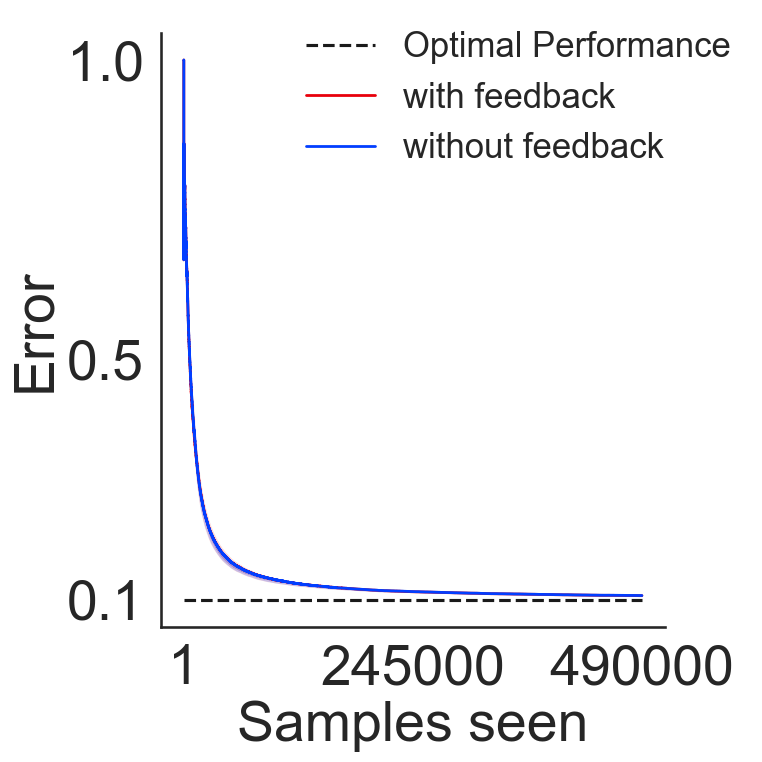

In [193]:
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40
samples_to_show = 490000

fig, ax = plt.subplots(1, 1, figsize=(8,8))

ax.hlines(0.1, 0, samples_to_show, linestyles='dashed', label='Optimal Performance', color='k')

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc_rnn[:5,:samples_to_show],axis=0),linewidth=2, c='r', label='with feedback')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc_rnn[:5,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc_rnn[:5,:samples_to_show], 0.75, axis=0), facecolor='r', alpha=.3)

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc_rnn_[:5,:samples_to_show],axis=0),linewidth=2, c='b', label='without feedback')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc_rnn_[:5,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc_rnn_[:5,:samples_to_show], 0.75, axis=0), facecolor='b', alpha=.3)

leg = fig.legend(fontsize=25, frameon=False)


ax.set_xticks([1, samples_to_show//2, samples_to_show])
ax.set_yticks([0.1, 0.5, 1.0])

ax.set_xlabel('Samples seen', fontsize=font)
ax.set_ylabel('Error', fontsize=font)

ax.tick_params(labelsize=40)
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

plt.tight_layout()


In [246]:
reps = 5
context_window = 1
lr = 1e-2

test_acc_rnn = np.zeros((reps, len(data)-1), dtype=float)


data_set = Dataset_converter(data[:60000], window=context_window)
data_set_test = Dataset_converter(data[60000:], window=context_window)
data_set_compressed = Dataset_converter(data[60000:], window=context_window)

for rep in tqdm(range(reps)):
    torch.manual_seed(rep)
    model = ElmanRNN(len(tokens), 20, 1)
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    # scheduler = lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.001, total_iters=100000)
    criterion = torch.nn.MSELoss()

    total = 0
    correct = 0
    jj = 0
    for X, y in train_loader:
        optimizer.zero_grad()

        if jj==0:
            predicted_y, hidden_memory = model(X)
        else:
            predicted_y, hidden_memory = model(X, mem)

        
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()     
        

        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1)

        with torch.no_grad():
            mem = hidden_memory.clone()
            total += 1
            
            if y.argmax() == predicted_y.argmax():
                    correct += 1

            test_acc_rnn[rep,jj] = correct/total

            if jj%10000 == 0:
                print(f'Iter : {jj+1}, loss: {loss:.4f}')
            jj += 1

    train_loader = DataLoader(data_set_compressed, batch_size=1, shuffle=False)   
    test_loader = DataLoader(data_set_test, batch_size=1, shuffle=False) 
    optimizer = torch.optim.SGD(model.parameters(), lr=lr*1e-8, momentum=0.9)

    for (X, y), (X_, y_) in zip(train_loader, test_loader):
        optimizer.zero_grad()

        if jj==0:
            predicted_y, hidden_memory = model(X)
        else:
            predicted_y, hidden_memory = model(X, mem)

        
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()     
        

        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1)

        with torch.no_grad():
            mem = hidden_memory.clone()

            predicted_y, _ = model(X_, mem)
            total += 1
            
            if y_.argmax() == predicted_y.argmax():
                    correct += 1

            test_acc_rnn[rep,jj] = correct/total

            if jj%10000 == 0:
                print(f'Iter : {jj+1}, loss: {loss:.4f}')
            jj += 1
            

  0%|                                                                                                                                                    | 0/5 [00:00<?, ?it/s]

Iter : 1, loss: 0.1212
Iter : 10001, loss: 0.0939
Iter : 20001, loss: 0.0798
Iter : 30001, loss: 0.0843
Iter : 40001, loss: 0.0804
Iter : 50001, loss: 0.0985
Iter : 60001, loss: 0.1559
Iter : 70001, loss: 0.0291
Iter : 80001, loss: 0.0623
Iter : 90001, loss: 0.0852
Iter : 100001, loss: 0.1314
Iter : 110001, loss: 0.0590
Iter : 120001, loss: 0.1323
Iter : 130001, loss: 0.0833
Iter : 140001, loss: 0.0591
Iter : 150001, loss: 0.0291
Iter : 160001, loss: 0.0837
Iter : 170001, loss: 0.0739
Iter : 180001, loss: 0.0591
Iter : 190001, loss: 0.0344
Iter : 200001, loss: 0.1220
Iter : 210001, loss: 0.1229
Iter : 220001, loss: 0.0294
Iter : 230001, loss: 0.0861
Iter : 240001, loss: 0.0841
Iter : 250001, loss: 0.0312
Iter : 260001, loss: 0.0849
Iter : 270001, loss: 0.0739
Iter : 280001, loss: 0.0852
Iter : 290001, loss: 0.1326
Iter : 300001, loss: 0.0693
Iter : 310001, loss: 0.0741
Iter : 320001, loss: 0.0728
Iter : 330001, loss: 0.1314
Iter : 340001, loss: 0.1282
Iter : 350001, loss: 0.1322
Iter :

 20%|███████████████████████████▊                                                                                                               | 1/5 [03:02<12:11, 182.78s/it]

Iter : 1, loss: 0.1159


 20%|███████████████████████████▊                                                                                                               | 1/5 [03:05<12:21, 185.45s/it]


KeyboardInterrupt: 

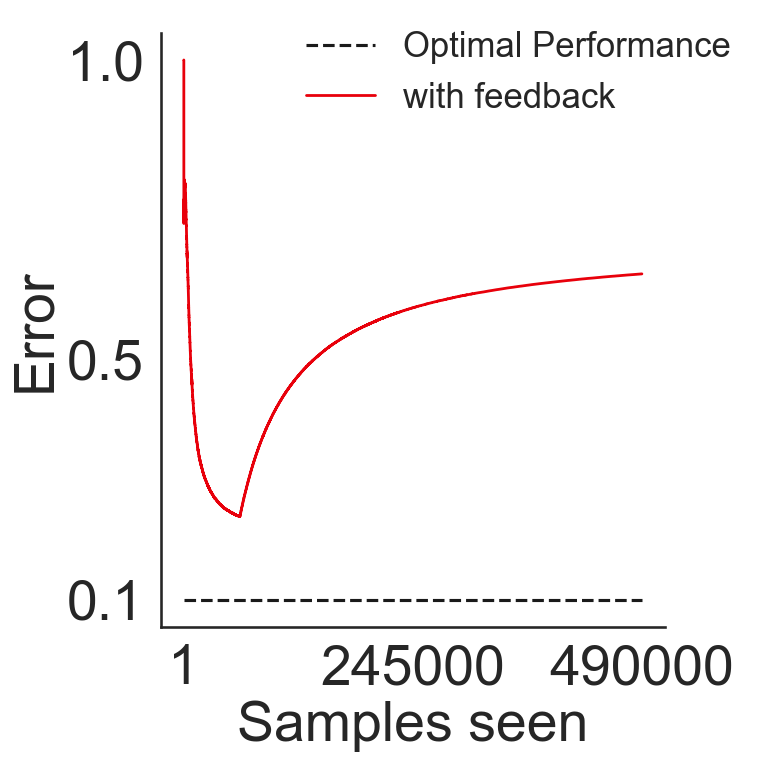

In [247]:
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40
samples_to_show = 490000

fig, ax = plt.subplots(1, 1, figsize=(8,8))

ax.hlines(0.1, 0, samples_to_show, linestyles='dashed', label='Optimal Performance', color='k')

ax.plot(np.arange(1,samples_to_show+1), np.median(1-test_acc_rnn[:1,:samples_to_show],axis=0),linewidth=2, c='r', label='with feedback')
ax.fill_between(np.arange(1,samples_to_show+1), np.quantile(1-test_acc_rnn[:1,:samples_to_show], 0.25, axis=0), np.quantile(1-test_acc_rnn[:1,:samples_to_show], 0.75, axis=0), facecolor='r', alpha=.3)

leg = fig.legend(fontsize=25, frameon=False)


ax.set_xticks([1, samples_to_show//2, samples_to_show])
ax.set_yticks([0.1, 0.5, 1.0])

ax.set_xlabel('Samples seen', fontsize=font)
ax.set_ylabel('Error', fontsize=font)

ax.tick_params(labelsize=40)
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

plt.tight_layout()
